# Initialization

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [3]:
import os
import pandas as pd 
import numpy as np
import wandb
import anndata as ad

from pathlib import Path

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [5]:
cwd = os.getcwd()
cwd

'/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/drvi_notebooks/evaluation'

In [6]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public')

In [7]:
output_dir = proj_dir / 'plots' / 'runtime_evaluation'
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

PosixPath('/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/plots/runtime_evaluation')

In [8]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

# Run Data

## Retrieve

In [9]:
RUN_KEYS = {
    "H100": "performance_supergpu14_H100_DRVI_runs_drvi_4.5",
    "A100": "performance_gpusrv72_A100_DRVI_runs_drvi_4.5",
    "V100": "performance_supergpu02_V100_DRVI_runs_drvi_4.5",
}

In [10]:
api = wandb.Api()
api.flush()

result_list = []
for run_config, run_key in RUN_KEYS.items():
    # Project is specified by <entity/project-name>
    runs = api.runs(run_key)
    
    for run in runs: 
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files 
        if run.tags and any([tag in ["remove"] for tag in run.tags]):
            continue
        system_metrics = run.history(stream='systemMetrics').max()
        system_metrics.index = system_metrics.index.str.replace('\\.', '_')
        result_list.append({
            'name': run.name,
            'summary': run.summary._json_dict,
            'config': {k: v for k,v in run.config.items() if not k.startswith('_')},
            'system_metrics': system_metrics.to_dict(),
            'run_config': run_config,
            'run_proj': run_key,
        })
    
runs_df = pd.json_normalize(result_list, sep='_')
runs_df = runs_df.query('(summary_epoch == config_params_max_epochs - 1)')

print("Number of runs:", len(runs_df))
runs_df[:3]

Number of runs: 81


,name,run_config,run_proj,summary__runtime,summary__step,summary__timestamp,summary__wandb_runtime,summary_elbo_train,summary_elbo_validation,summary_epoch,...,config_model_decoder_layer_factory,config_model_decoder_reuse_weights,config_model_encoder_layer_factory,config_model_categorical_covariates,config_model_fill_in_the_blanks_ratio,config_model_covariate_modeling_strategy,config_train_accelerator,config_data_setup_is_count_data,config_model_n_layers_decoder,config_model_n_layers_encoder
0,scvi_20250120-171026-592591,H100,performance_supergpu14_H100_DRVI_runs_drvi_4.5,208.266031,2489,1.737390e+09,213,4118.599121,4113.849121,99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,drvi_20250120-170603-700270,H100,performance_supergpu14_H100_DRVI_runs_drvi_4.5,255.201651,2489,1.737389e+09,255,4121.929688,4117.947754,99,...,FCLayerFactory(residual_preferred=False),everywhere,FCLayerFactory(residual_preferred=False),[batch@5],0.0,one_hot,gpu,True,NaN,NaN
2,drvi_20250120-165950-142935,H100,performance_supergpu14_H100_DRVI_runs_drvi_4.5,343.613014,2489,1.737389e+09,349,4139.291016,4160.305664,99,...,FCLayerFactory(residual_preferred=False),everywhere,FCLayerFactory(residual_preferred=False),[batch@5],0.0,one_hot,gpu,True,NaN,NaN


## Runtime comparison

In [11]:
dataset_sizes = {
    adata_path: ad.read_h5ad(adata_path, backed="r").shape
    for adata_path in runs_df["config_params_input_adata"].unique()
}

In [12]:
runs_df["dataset"] = runs_df["config_params_input_adata"].str.rsplit("/", n=1).str[1].map({
    'zebrafish_processed_v1_hvg_2000.h5ad': 'Daniocell',
    'hlca_core_hvg.h5ad': 'Human lung cell atlas',
    'haniffa21_rna_hvg.h5ad': 'PBMC',
    'retina_organoid_hvg.h5ad': 'Retina organoid',
    'norman_2019_hvg.h5ad': 'CRISPR screen',
    'pancreas_scvelo_hvg.h5ad': 'Developmental pancreas',
    'adata_hvg.h5ad': 'Immune',
    'immune_all_genes.h5ad': 'Immune (all genes)',
    'atac_modality_hvg.h5ad': 'scATAC-seq NeurIPS 2021',
})
runs_df["paper_epochs"] = runs_df["config_params_input_adata"].str.rsplit("/", n=1).str[1].map({
    'zebrafish_processed_v1_hvg_2000.h5ad': 400,
    'hlca_core_hvg.h5ad': 400,
    'haniffa21_rna_hvg.h5ad': 400,
    'retina_organoid_hvg.h5ad': 400,
    'norman_2019_hvg.h5ad': 400,
    'pancreas_scvelo_hvg.h5ad': 1000,
    'adata_hvg.h5ad': 400,
    'immune_all_genes.h5ad': 400,
    'atac_modality_hvg.h5ad': 400,
})
runs_df["n_cells"] = runs_df["config_params_input_adata"].apply(lambda path: dataset_sizes[path][0])
runs_df["n_genes"] = runs_df["config_params_input_adata"].apply(lambda path: dataset_sizes[path][1])
runs_df["runtime_per_sample"] = 1000 * runs_df["summary_train_runtime"] / runs_df["n_cells"] / runs_df["config_params_max_epochs"]
runs_df["runtime_paper"] = runs_df["summary_train_runtime"] / 100 * runs_df["paper_epochs"]
runs_df["model_plot"] = runs_df["config_params_model"].map({'drvi': 'DRVI', 'scvi': 'scVI family baseline', 'peakvi': 'scVI family baseline'})
runs_df["dataset_plot"] = runs_df["dataset"] + "\n#cells: " + np.round(runs_df["n_cells"] / 1000).astype("int").astype(str) + "k\n#features: " + runs_df["n_genes"].astype("str")

runs_df[[
    "run_config", "summary_train_runtime", "dataset", "n_cells", "n_genes",
    "config_params_model", "config_params_n_latent", 
    "config_params_n_split_latent", "config_params_max_epochs", 
]]

,run_config,summary_train_runtime,dataset,n_cells,n_genes,config_params_model,config_params_n_latent,config_params_n_split_latent,config_params_max_epochs
0,H100,204.262282,Immune (all genes),32484,12303,scvi,64,1,100
1,H100,224.055636,Immune (all genes),32484,12303,drvi,64,1,100
2,H100,312.729938,Immune (all genes),32484,12303,drvi,64,64,100
3,H100,793.979051,scATAC-seq NeurIPS 2021,69247,14865,drvi,64,64,100
4,H100,452.509567,scATAC-seq NeurIPS 2021,69247,14865,drvi,64,1,100
...,...,...,...,...,...,...,...,...,...
76,V100,262.451211,Immune (all genes),32484,12303,drvi,64,1,100
77,V100,629.822665,Immune (all genes),32484,12303,drvi,64,64,100
78,V100,210.419574,Immune,32484,2000,drvi,32,32,100
79,V100,191.532823,Immune,32484,2000,drvi,32,1,100


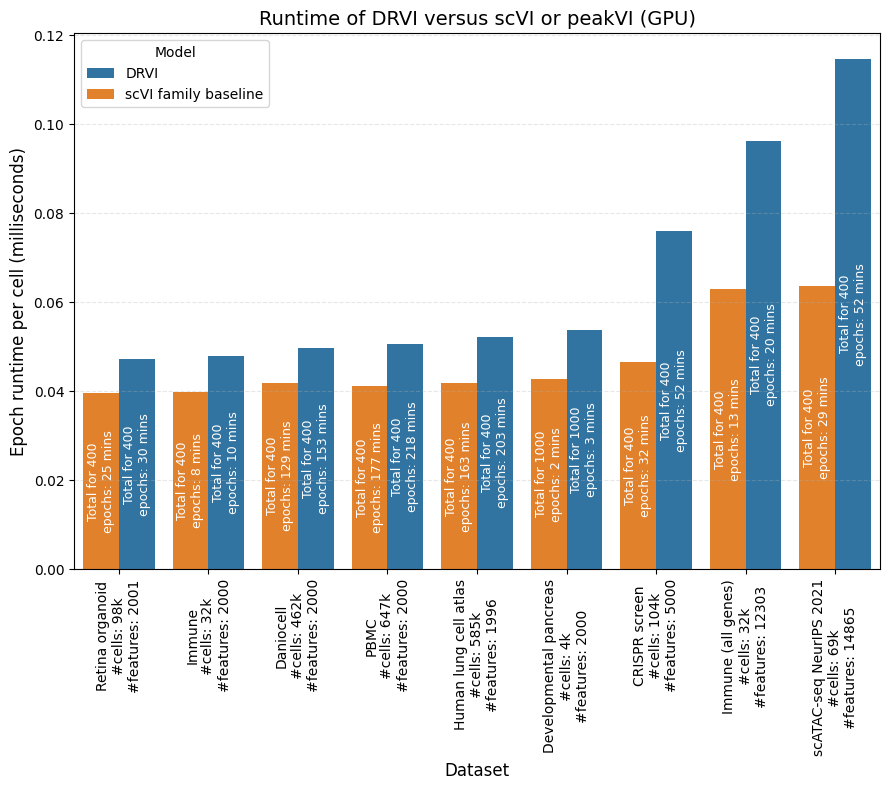

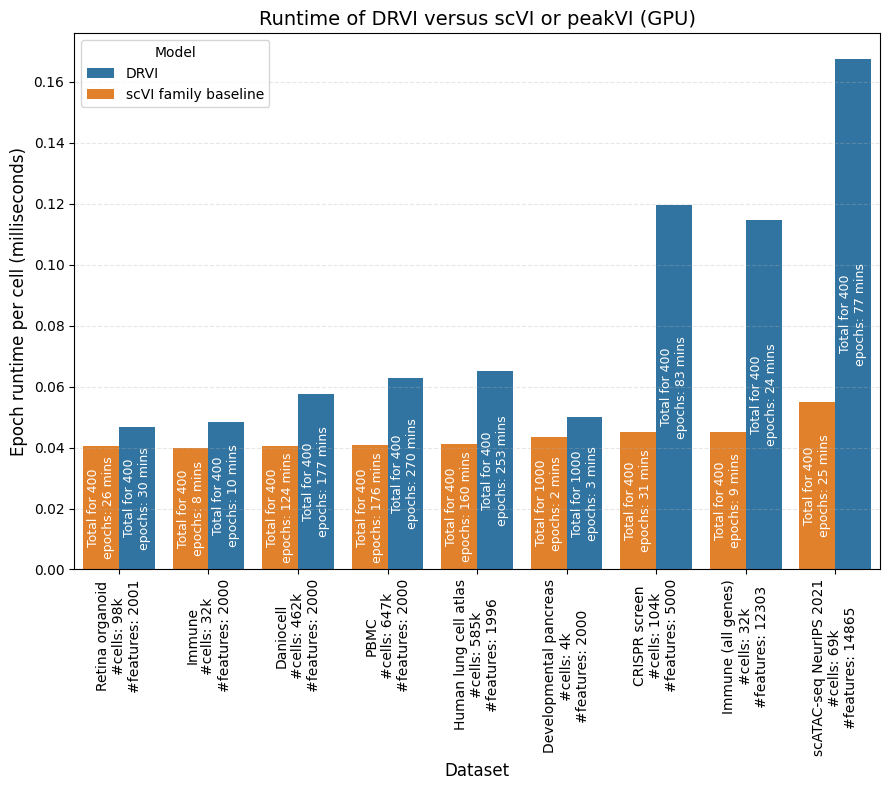

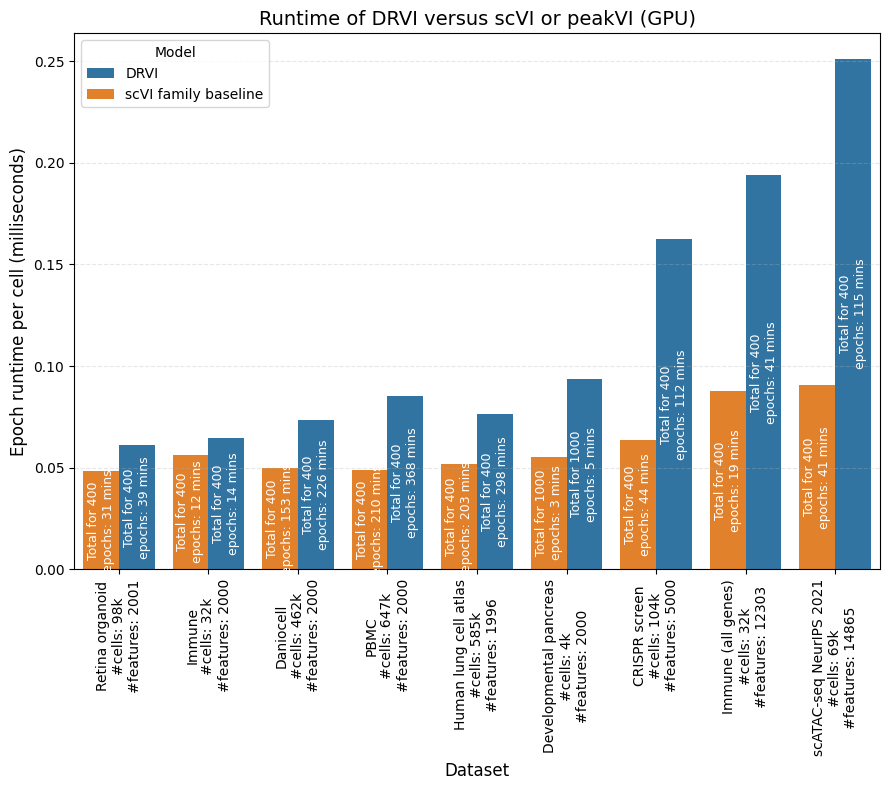

In [13]:
x_order = None
for run_config in ["H100", "A100", "V100"]:
    filtered_runs_df = (
        runs_df
        .query(f"run_config=='{run_config}'")
        .query("(config_params_model != 'drvi') | (config_params_n_split_latent > 1)") # Remove DRVI with no split
        .sort_values("runtime_per_sample", ascending=False)
    )
    if x_order is None:
        x_order = filtered_runs_df.drop_duplicates(subset=['dataset_plot'])['dataset_plot']
    
    # Plot runtime vs dataset with models as groups
    plt.figure(figsize=(9, 8))
    barplot = sns.barplot(
        data=filtered_runs_df,
        x='dataset_plot',
        y='runtime_per_sample',
        order=x_order,
        hue='model_plot',
        hue_order=sorted(runs_df['model_plot'].unique()),
        dodge=True,  # Avoid gaps by overlapping bars slightly
        palette='tab10'
    )
    
    # Add total runtime text on each bar, positioned at the center
    for container in barplot.containers:
        assert filtered_runs_df['runtime_per_sample'].nunique() == len(filtered_runs_df)
        height_mapping_runtime_paper = dict(zip(filtered_runs_df['runtime_per_sample'], filtered_runs_df['runtime_paper']))
        height_mapping_epochs_paper = dict(zip(filtered_runs_df['runtime_per_sample'], filtered_runs_df['paper_epochs']))
        barplot.bar_label(container, labels=[f"Total for {height_mapping_epochs_paper[height]}\nepochs: {int(height_mapping_runtime_paper[height] / 60)} mins" for height in container.datavalues],
                          fontsize=9, label_type='center', rotation=90, color='white')  # Adjust pad for spacing
    
    # Customize the plot
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('Epoch runtime per cell (milliseconds)', fontsize=12)
    plt.title(f'Runtime of DRVI versus scVI or peakVI (GPU)', fontsize=14)
    plt.xticks(fontsize=10, rotation=90, ha='center')
    plt.yticks(fontsize=10)
    plt.legend(title='Model', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.gca().invert_xaxis()
    
    # Show the plot
    plt.tight_layout()
    plt.savefig(output_dir / f"runtime_barplot_{run_config}.pdf", bbox_inches='tight')
    plt.show()

In [14]:
import drvi
import pickle
from datetime import datetime

In [15]:
last_adata_path = None
adata = None

if not (output_dir / "downstream_runtimes.pkl").exists():
    downstream_runtimes = {}
    with open(output_dir / "downstream_runtimes.pkl", "wb") as f:
        pickle.dump(downstream_runtimes, f)

with open(output_dir / "downstream_runtimes.pkl", "rb") as f:
    downstream_runtimes = pickle.load(f)
    
for _, row in (
    runs_df
    .query("run_config == 'H100'")
    .query("(config_params_model == 'drvi') & (config_params_n_split_latent > 1)")
    .sort_values("config_params_input_adata").iterrows()
):
    run_id = row["name"]
    print(run_id)
    if run_id in downstream_runtimes:
        print("Already calculated")
        continue
    if last_adata_path != row.config_params_input_adata:
        adata = ad.read_h5ad(row.config_params_input_adata, backed="r")
        last_adata_path = row.config_params_input_adata 

    model = drvi.model.DRVI.load(logs_dir / "models" / run_id / "model.pt", adata)
    embed = ad.read(logs_dir / "models" / run_id / "latent.h5ad")

    latent_dim_stats_start = datetime.now()
    drvi.utils.tl.set_latent_dimension_stats(model, embed)
    latent_dim_stats_runtime = (datetime.now() - latent_dim_stats_start).total_seconds()
    
    interpretability_start = datetime.now()
    traverse_adata = drvi.utils.tl.traverse_latent(model, embed, n_samples=20, max_noise_std=0.0)
    drvi.utils.tl.calculate_differential_vars(traverse_adata)
    interpretability_runtime = (datetime.now() - interpretability_start).total_seconds()

    print(latent_dim_stats_runtime, interpretability_runtime)
    downstream_runtimes[run_id] = {
        "latent_dim_stats_runtime": latent_dim_stats_runtime,
        "interpretability_runtime": interpretability_runtime,
    }


drvi_20250116-172222-115026
Already calculated
drvi_20250116-124013-338813
Already calculated
drvi_20250116-220201-989284
Already calculated
drvi_20250116-144909-473509
Already calculated
drvi_20250116-124240-545046
Already calculated
drvi_20250116-123605-258891
Already calculated
drvi_20250120-165950-142935
Already calculated
drvi_20250116-133137-319176
Already calculated
drvi_20250116-202246-148521
Already calculated


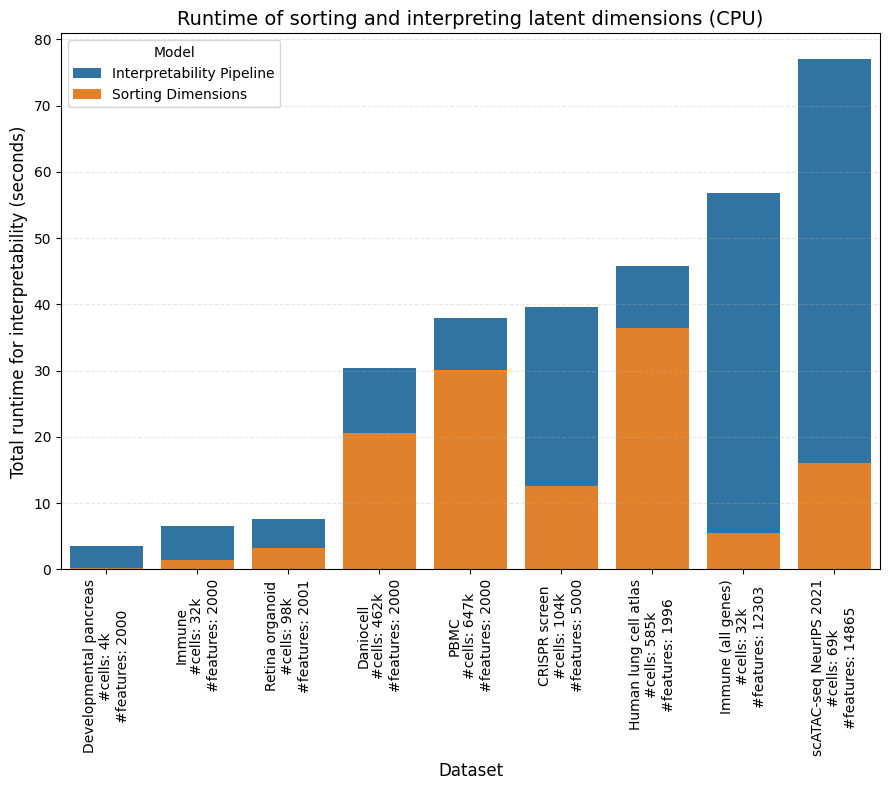

In [16]:
run_config = 'H100'  # Does not matter

filtered_runs_df = (
    runs_df
    .query(f"run_config == '{run_config}'")
    .query("(config_params_model == 'drvi') & (config_params_n_split_latent > 1)")
    .sort_values("runtime_per_sample", ascending=False)
)
filtered_runs_df['latent_dim_stats_runtime'] = filtered_runs_df['name'].apply(lambda run_id: downstream_runtimes[run_id]["latent_dim_stats_runtime"])
filtered_runs_df['interpretability_runtime'] = filtered_runs_df['name'].apply(lambda run_id: downstream_runtimes[run_id]["interpretability_runtime"])


filtered_runs_df = (
    filtered_runs_df
    .melt(id_vars=['dataset_plot'], value_vars=['latent_dim_stats_runtime', 'interpretability_runtime'],
          var_name='operation', value_name='runtime')
)
filtered_runs_df['operation_plot'] = filtered_runs_df['operation'].map({'latent_dim_stats_runtime': 'Sorting Dimensions',
                                      'interpretability_runtime': 'Interpretability Pipeline'})
filtered_runs_df

filtered_runs_df['cum_runtime'] = filtered_runs_df.groupby('dataset_plot')['runtime'].cumsum()
filtered_runs_df.sort_values('cum_runtime', ascending=False, inplace=True)

plt.figure(figsize=(9, 8))
barplot = sns.barplot(
    data=filtered_runs_df,
    x='dataset_plot',
    y='cum_runtime',
    hue='operation_plot',
    hue_order=sorted(filtered_runs_df['operation_plot'].unique()),
    dodge=False,  # Avoid gaps by overlapping bars slightly
    palette='tab10'
)

# Add total runtime text on each bar, positioned at the center
# for container in barplot.containers:
#     barplot.bar_label(container, labels=[f"{int(height)} seconds" for height in container.datavalues],
#                       fontsize=9, label_type='center', rotation=90, color='white')  # Adjust pad for spacing

# Customize the plot
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Total runtime for interpretability (seconds)', fontsize=12)
plt.title(f'Runtime of sorting and interpreting latent dimensions (CPU)', fontsize=14)
plt.xticks(fontsize=10, rotation=90, ha='center')
plt.yticks(fontsize=10)
plt.legend(title='Model', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().invert_xaxis()

# Show the plot
plt.tight_layout()
plt.savefig(output_dir / f"downstream_share_of_runtime_barplot_{run_config}.pdf", bbox_inches='tight')
plt.show()

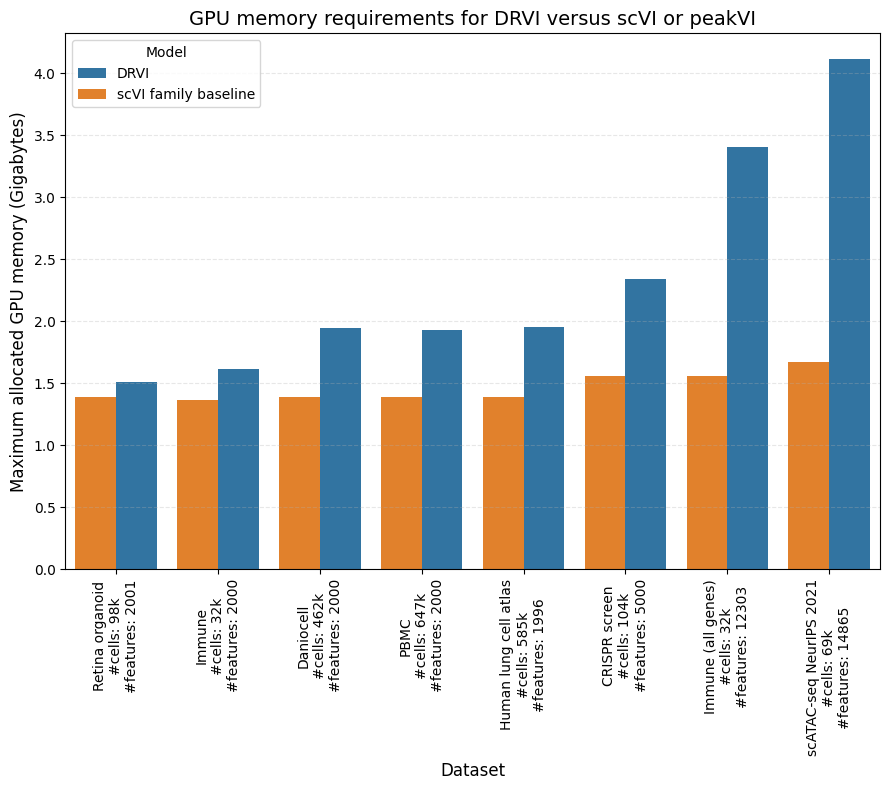

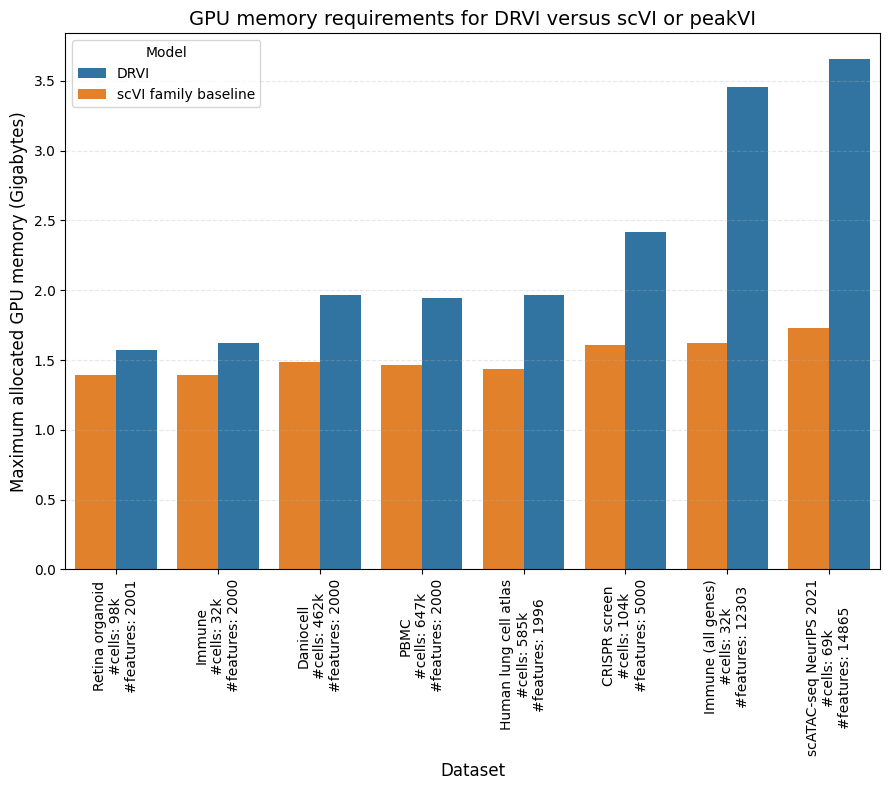

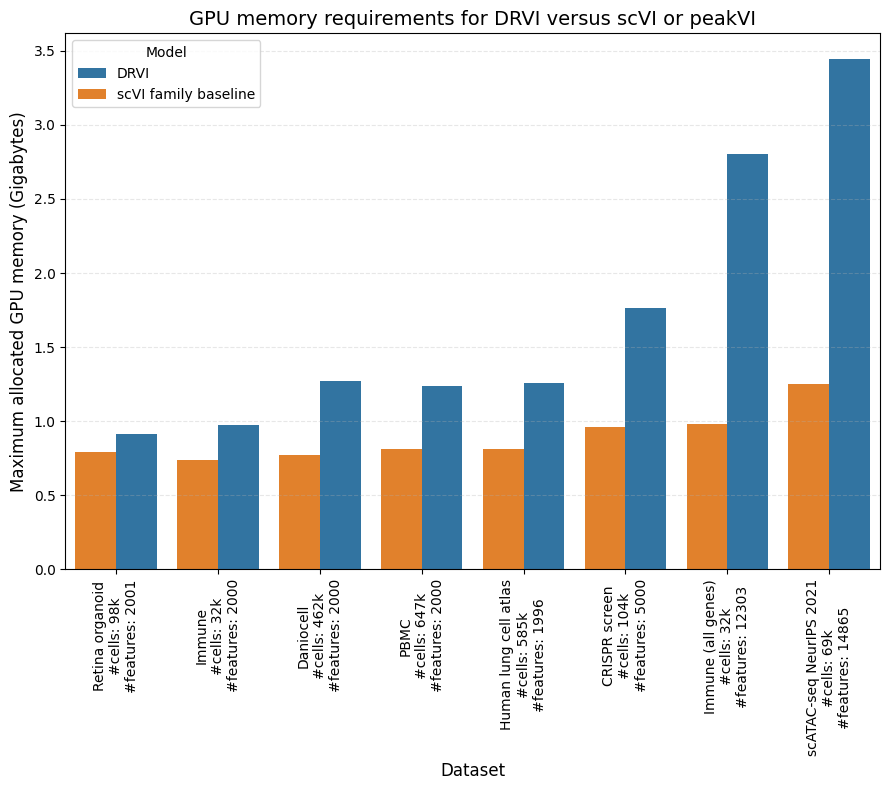

In [17]:
x_order = None
for run_config in ["H100", "A100", "V100"]:
    filtered_runs_df = (
        runs_df
        .query("dataset != 'Developmental pancreas'")
        .query(f"run_config=='{run_config}'")
        .query("(config_params_model != 'drvi') | (config_params_n_split_latent > 1)") # Remove DRVI with no split
        .sort_values("runtime_per_sample", ascending=False)
    )
    if x_order is None:
        x_order = filtered_runs_df.drop_duplicates(subset=['dataset_plot'])['dataset_plot']
    
    filtered_runs_df['gpu_memory_gb'] = filtered_runs_df['system_metrics_system_gpu_0_memoryAllocatedBytes'] / 1e9
    
    # Plot runtime vs dataset with models as groups
    plt.figure(figsize=(9, 8))
    barplot = sns.barplot(
        data=filtered_runs_df,
        x='dataset_plot',
        y='gpu_memory_gb',
        order=x_order,
        hue='model_plot',
        hue_order=sorted(runs_df['model_plot'].unique()),
        dodge=True,  # Avoid gaps by overlapping bars slightly
        palette='tab10'
    )
    
    # Customize the plot
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('Maximum allocated GPU memory (Gigabytes)', fontsize=12)
    plt.title(f'GPU memory requirements for DRVI versus scVI or peakVI', fontsize=14)
    plt.xticks(fontsize=10, rotation=90, ha='center')
    plt.yticks(fontsize=10)
    plt.legend(title='Model', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.gca().invert_xaxis()
    
    # Show the plot
    plt.tight_layout()
    plt.savefig(output_dir / f"gpu_memory_barplot_{run_config}.pdf", bbox_inches='tight')
    plt.show()